# Explorativní analýza
Pro analýzu byla použita datová sada Stroke Prediction Dataset ze stránky Kaggle.com (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?resource=download).
## Prozkoumání atributů
Nejprve načteme data z csv souboru do pandas dataframe. 


In [88]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df = df.drop(columns="id")

Provedeme analýzu dat jako celek. Vypíšeme si datové typy jednotlivých atribůtu a pár dat od každého pro základní pochopení dat. 

In [89]:
print("Informace o datech:")
print(df.info())

print("Ukázka dat:")
print(df.head())

Informace o datech:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB
None
Ukázka dat:
   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0 

Dále si zobrazíme souhrné statistiky o datech pro získání přehledu o rozsahu a počtu dat.

In [90]:
print("Popisná statistika číselných atributů:")
print(df[["age", "avg_glucose_level", "bmi"]].describe().T)
print("---------------------------------------------------------------------")
print("Popisná statistika kategorických atributů:")
df["c_hypertension"] = df["hypertension"].astype("str")
df["c_heart_disease"] = df["heart_disease"].astype("str")
df["c_stroke"] = df["stroke"].astype("str")
print(df.describe(include=['object']).T)

Popisná statistika číselných atributů:
                    count        mean        std    min     25%     50%  \
age                5110.0   43.226614  22.612647   0.08  25.000  45.000   
avg_glucose_level  5110.0  106.147677  45.283560  55.12  77.245  91.885   
bmi                4909.0   28.893237   7.854067  10.30  23.500  28.100   

                      75%     max  
age                 61.00   82.00  
avg_glucose_level  114.09  271.74  
bmi                 33.10   97.60  
---------------------------------------------------------------------
Popisná statistika kategorických atributů:
                count unique           top  freq
gender           5110      3        Female  2994
ever_married     5110      2           Yes  3353
work_type        5110      5       Private  2925
Residence_type   5110      2         Urban  2596
smoking_status   5110      4  never smoked  1892
c_hypertension   5110      2             0  4612
c_heart_disease  5110      2             0  4834
c_stroke   

## Grafy

Prozkoumáme rozložení hodnot pomocí vhodných grafu.

Prvně jsme vytvořili grafy zobrazující pravděpodobnost mozkové příhody v závislosti na hodnotách jednotilých atributů.

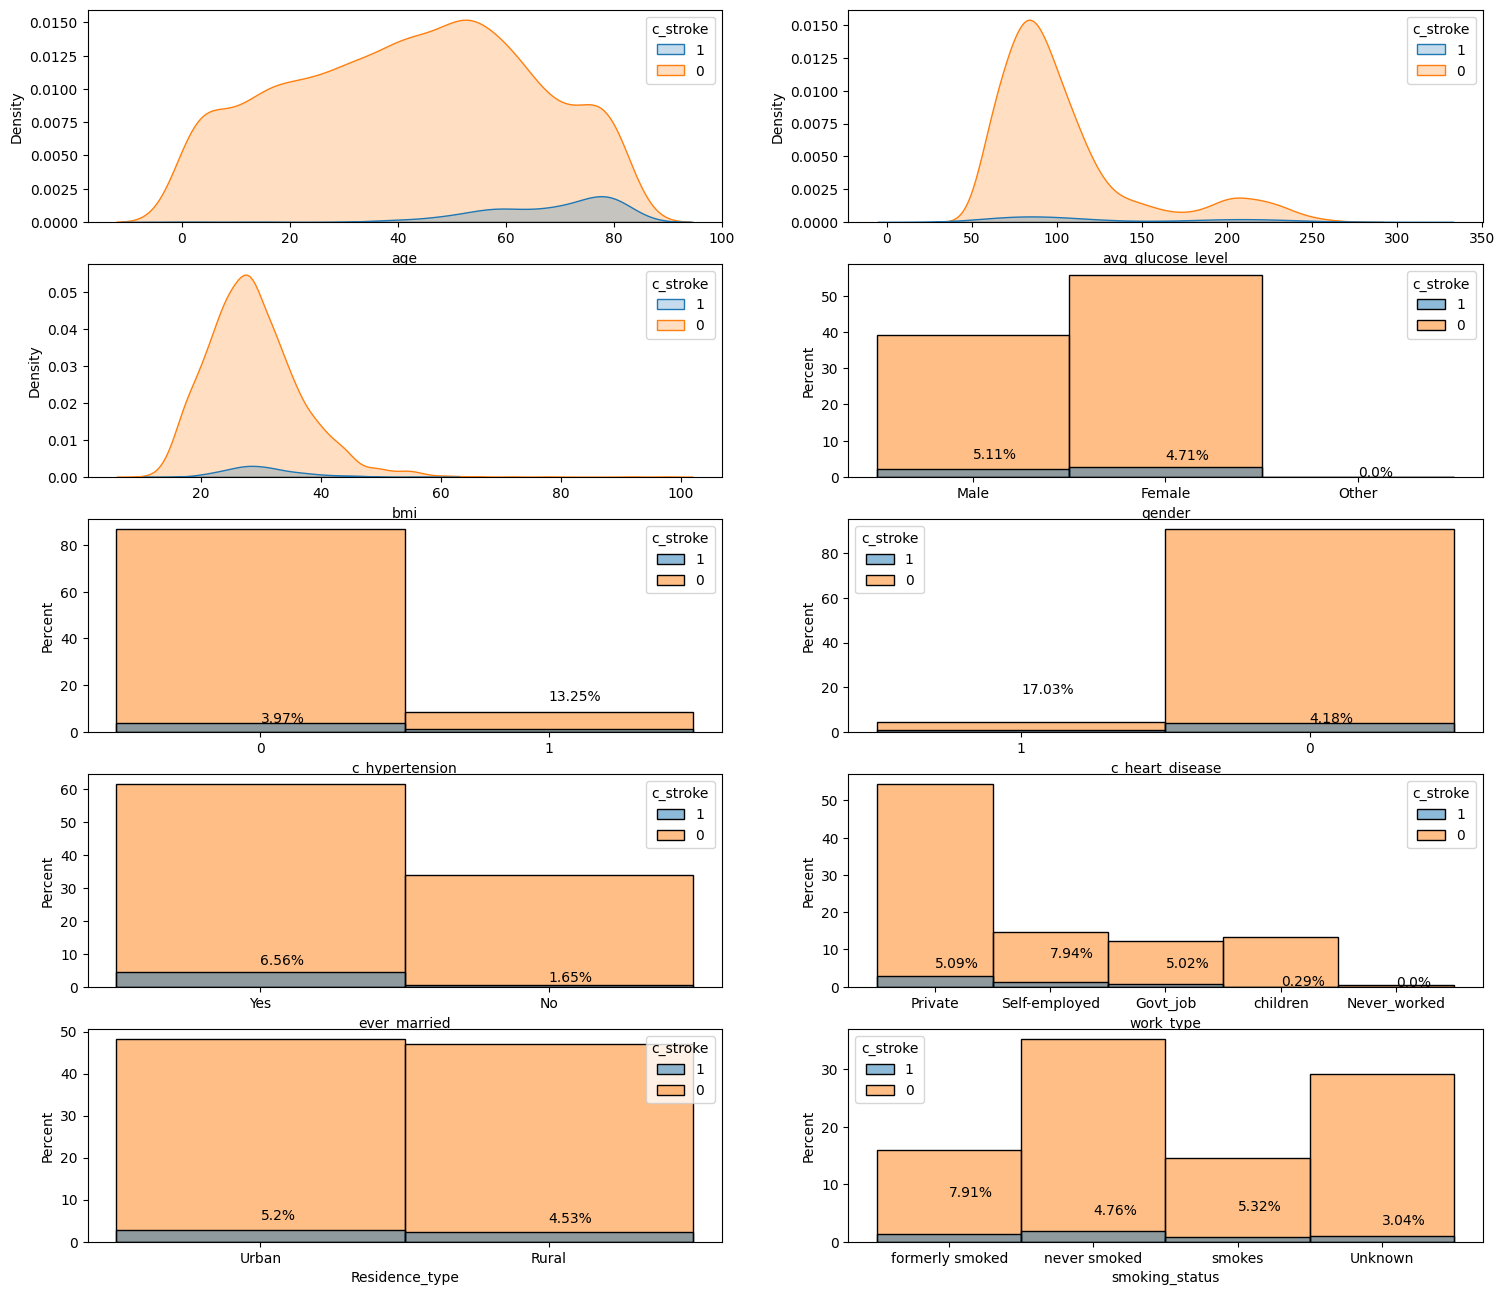

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(5, 2, figsize=(18, 16))
ax = ax.flatten()

numerical = ["age", "avg_glucose_level", "bmi"]
categorical = ["gender", "c_hypertension", "c_heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]

# Numerical
for idx, attr in enumerate(numerical):
    sns.kdeplot(data=df, x=attr, hue="c_stroke", fill=True, ax=ax[idx])
# Categorical
for idx, attr in enumerate(categorical, start=3):
    sns.histplot(data=df, x=attr, hue="c_stroke", fill=True, ax=ax[idx], stat="percent")


    categories = [tick.get_text() for tick in ax[idx].get_xticklabels()]
    for category in categories:
        perc = df[(df[attr] == category) & (df['c_stroke'] == "1")].shape[0]/df[df[attr] == category].shape[0]
        x_pos = list(categories).index(category)
        ax[idx].text(
            x=x_pos,
            y=perc*100,
            s=f"{str(np.round(perc*100, decimals=2))}%"
        )

Zachení závislosti mezi typem práce, věkem a mozkovou příhodou.

Text(0.5, 1.0, 'Vztah mezi typem práce, věkem a mozkovou příhodou')

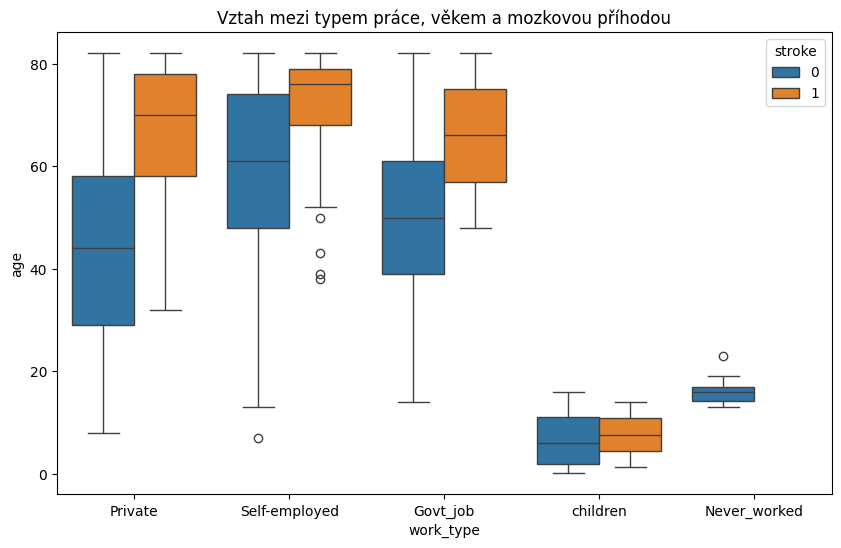

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y="age", x="work_type", hue="stroke")
plt.title("Vztah mezi typem práce, věkem a mozkovou příhodou")

Také jsme vytvořily scatterplot grafy, které nám mohou prozradit korelaci mezi numerickými hodnotami.

<Axes: xlabel='bmi', ylabel='avg_glucose_level'>

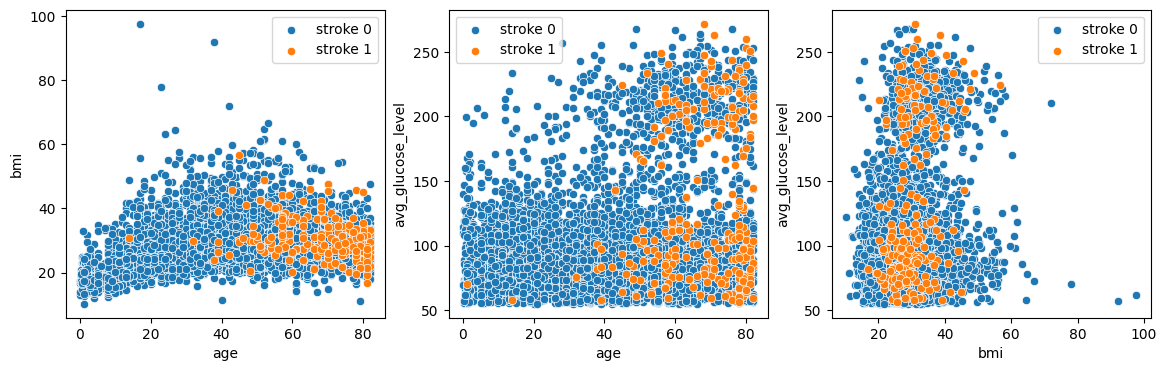

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(1, 3, figsize=(14,4))
# age - bmi
sns.scatterplot(data=df[df["stroke"] == 0], x='age', y='bmi', ax=ax[0], label="stroke 0")
sns.scatterplot(data=df[df["stroke"] == 1], x='age', y='bmi', ax=ax[0], label="stroke 1")
# age - glucose
sns.scatterplot(data=df[df["stroke"] == 0], x='age', y='avg_glucose_level', ax=ax[1], label="stroke 0")
sns.scatterplot(data=df[df["stroke"] == 1], x='age', y='avg_glucose_level', ax=ax[1], label="stroke 1")
# bmi - glucose
sns.scatterplot(data=df[df["stroke"] == 0], x='bmi', y='avg_glucose_level', ax=ax[2], label="stroke 0")
sns.scatterplot(data=df[df["stroke"] == 1], x='bmi', y='avg_glucose_level', ax=ax[2], label="stroke 1")

Zde vytváříme grafy zobrazující trendy mezi všemi kategorickými a numerickými hodnotami.

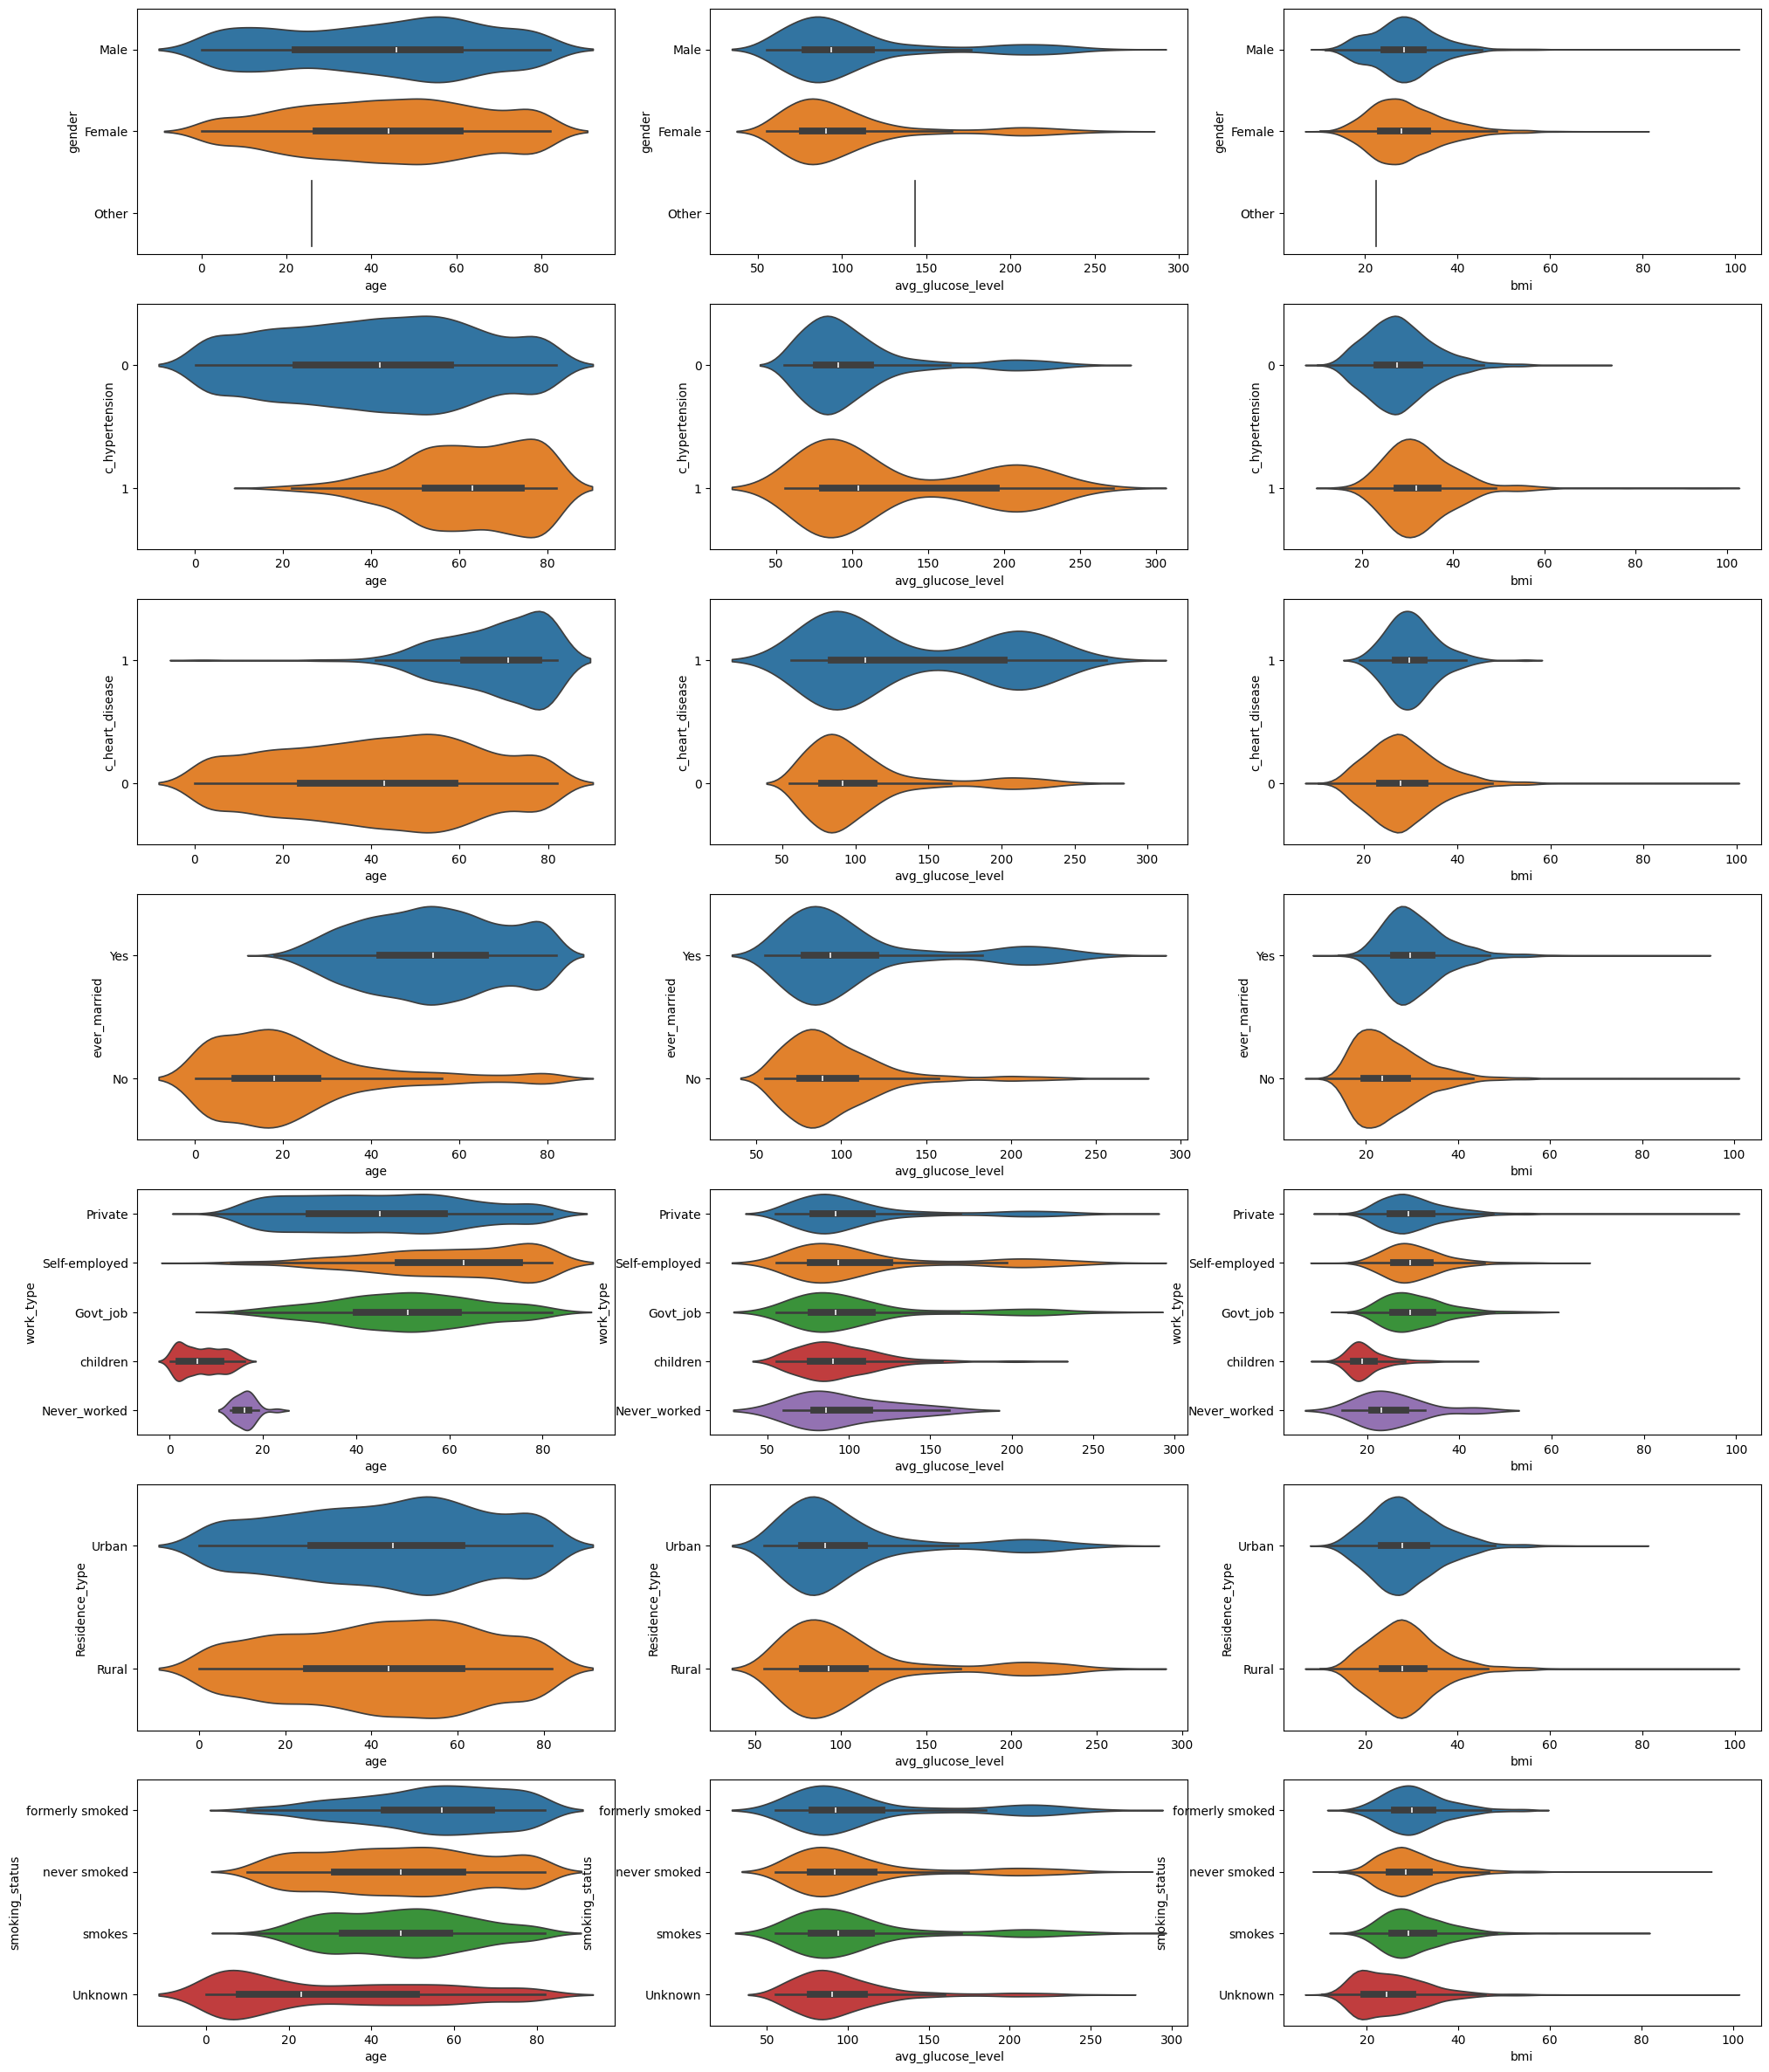

In [93]:
fig, ax = plt.subplots(len(categorical), len(numerical), figsize=(24,30))

for i, n_attr in enumerate(numerical):
    for j, c_attr in enumerate(categorical): 
        sns.violinplot(data=df, x=n_attr, y=c_attr, hue=c_attr, ax=ax[j][i])
plt.show() 

Zde vytváříme grafy pro zobrazení procentuálního zastoupení lidí s mozkovou příhodou v různých skupinách, kde tyto skupiny jsou definovány hodnotami vybraných atributů. 

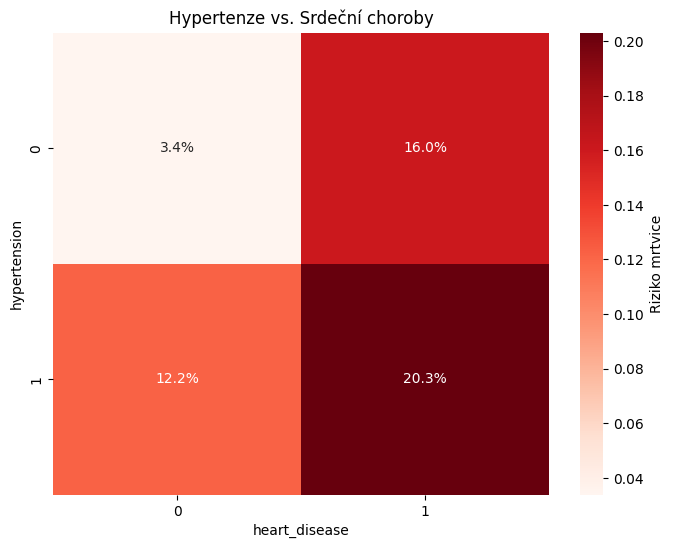

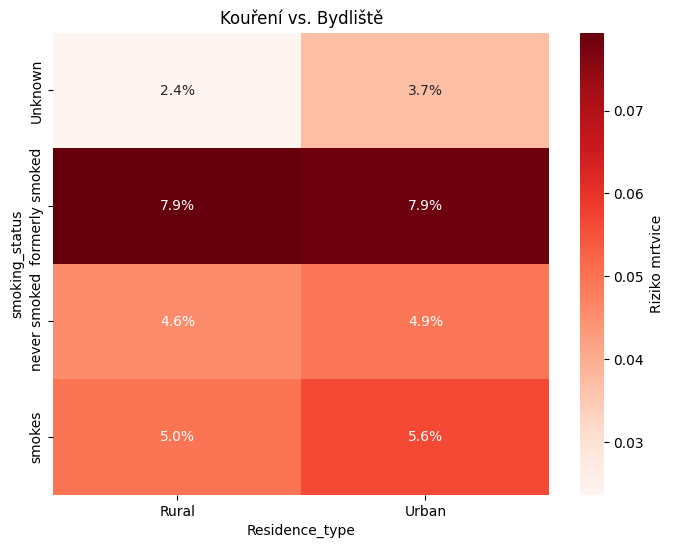

In [74]:
comorbidity_risk = pd.pivot_table(df, values='stroke', index='hypertension', 
                                  columns='heart_disease', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(comorbidity_risk, annot=True, fmt=".1%", cmap='Reds', cbar_kws={'label': 'Riziko mrtvice'})
plt.title('Hypertenze vs. Srdeční choroby')
plt.show()

comorbidity_risk = pd.pivot_table(df, values='stroke', index='smoking_status', 
                                  columns='Residence_type', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(comorbidity_risk, annot=True, fmt=".1%", cmap='Reds', cbar_kws={'label': 'Riziko mrtvice'})
plt.title('Kouření vs. Bydliště')
plt.show()

Také vytvoříme korelační matici pro zobrazní korelace numerických atributů pomocí korelačních koeficientů.

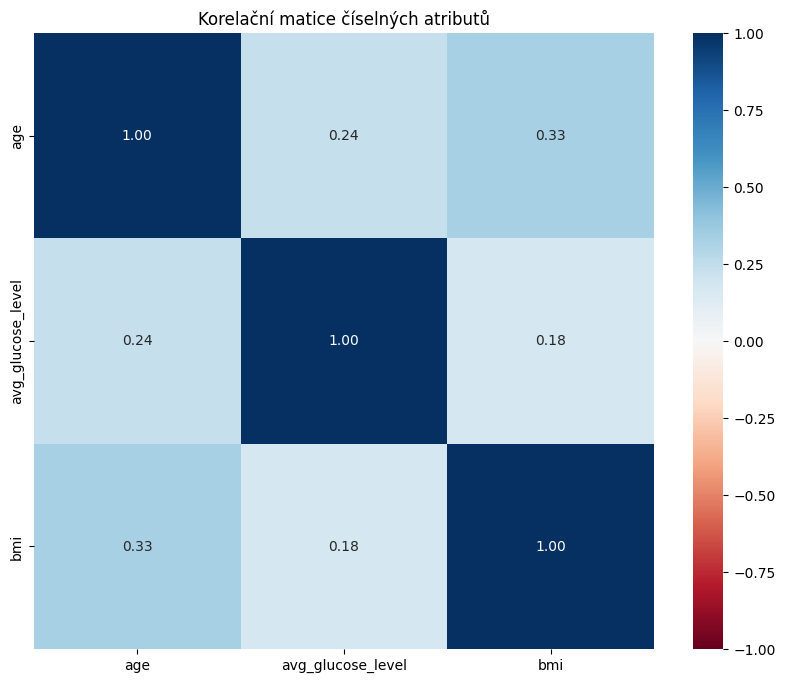

In [75]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelační matice číselných atributů')
plt.show()

In [76]:
# remove temporary categorical columns
df = df.drop(columns=["c_hypertension", "c_heart_disease", "c_stroke"])

## Odlehlé hodnoty
Nejdříve provedeme analýzu numerických odlehlých hodnot a po pomocí IQR a pomocí Z-score. 

In [77]:
# Detekce pomocí IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detekce pomocí Z-Score
def detect_outliers_zscore(df, column, threshold=3):
    col_data = df[column].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    outliers = col_data[z_scores > threshold]
    return outliers


for col in [['age', 'Věk'], ['avg_glucose_level', 'Průměrná hladina glukózy'], ['bmi', 'BMI']]:
    print(f"{col[1]}: ")
    outliers_iqr = detect_outliers_iqr(df, col[0])
    print(" Pomocí IQR")
    print(f"  Počet nalezených odlehlých hodnot: {len(outliers_iqr)}")
    print(f"  Ukázka hodnot: {outliers_iqr[col[0]].values[:5]}")
    
    outliers_z = detect_outliers_zscore(df, col[0])
    print("Pomocí Z-Score")
    print(f"  Počet nalezených odlehlých hodnot: {len(outliers_z)}")
    print(f"  Ukázka hodnot: {outliers_z.values[:5]}")

    

Věk: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 0
  Ukázka hodnot: []
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 0
  Ukázka hodnot: []
Průměrná hladina glukózy: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 627
  Ukázka hodnot: [228.69 202.21 171.23 174.12 186.21]
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 49
  Ukázka hodnot: [252.72 243.58 259.63 249.31 263.32]
BMI: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 110
  Ukázka hodnot: [48.9 56.6 50.1 54.6 60.9]
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 58
  Ukázka hodnot: [56.6 54.6 60.9 54.7 64.8]


Vidíme že IQR nalezlo velké množství hodnot vzhledem k velikosti celé datové sadě a tedy Z-score se jeví pro detekci jako lepší řešení. 

Dále provedeme analýzu odlehlých hodnot u kategorických atributů a to pomocí histogramů.

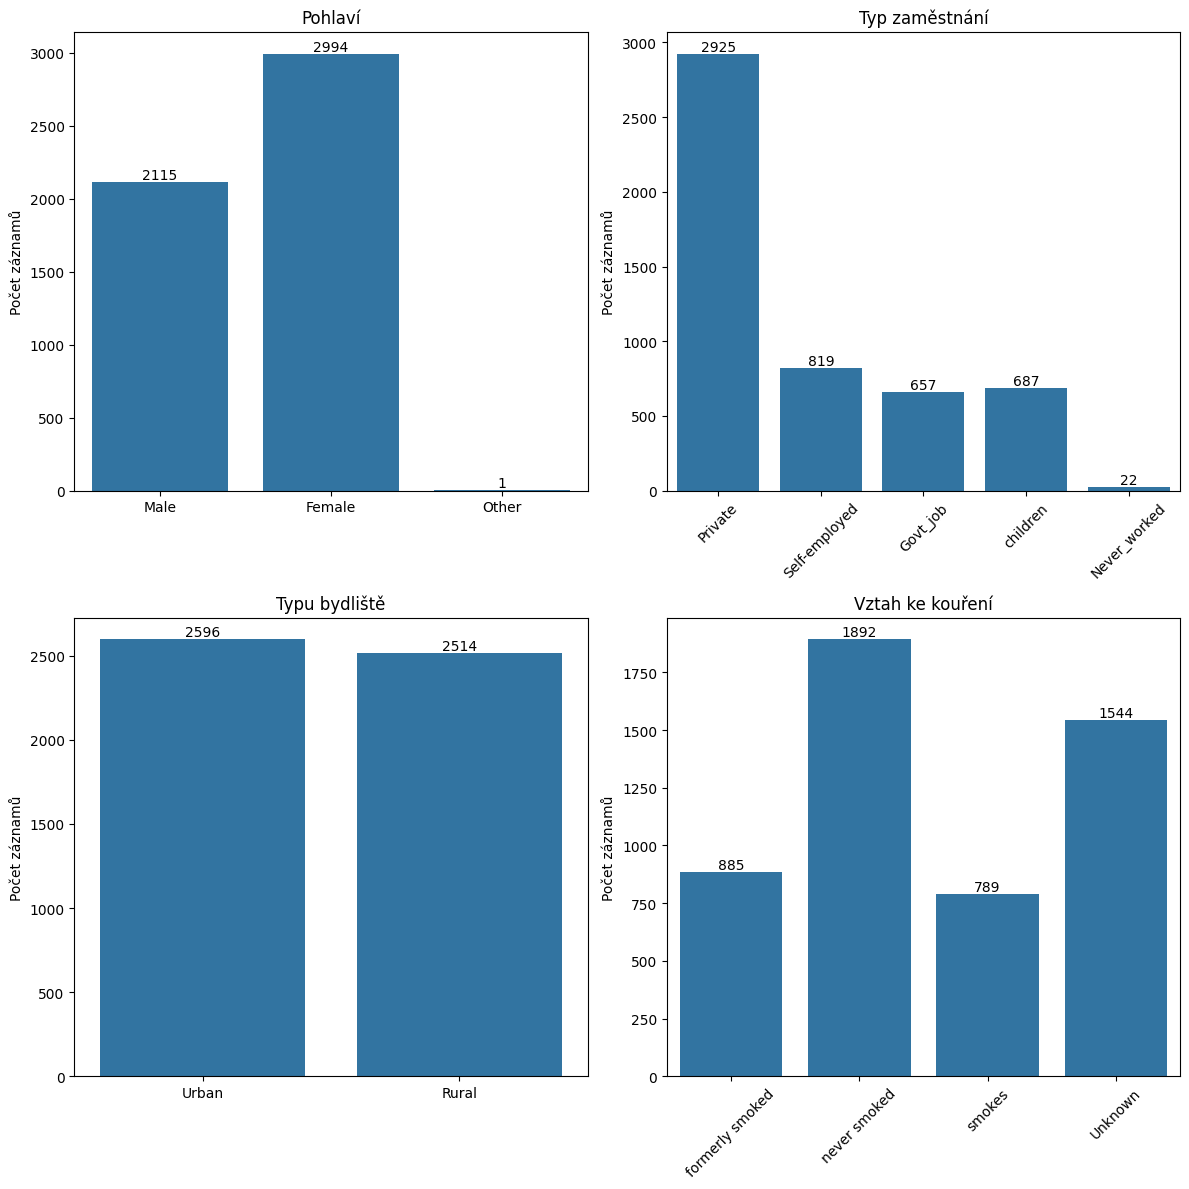

In [78]:

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

sns.countplot(data=df, x='gender', ax=axes[0, 0])
axes[0, 0].set_title("Pohlaví")
axes[0, 0].set_ylabel('Počet záznamů')

sns.countplot(data=df, x='work_type', ax=axes[0, 1])
axes[0, 1].set_title("Typ zaměstnání")
axes[0, 1].set_ylabel('Počet záznamů')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Residence_type', ax=axes[1, 0])
axes[1, 0].set_title("Typu bydliště")
axes[1, 0].set_ylabel('Počet záznamů')

sns.countplot(data=df, x='smoking_status', ax=axes[1, 1])
axes[1, 1].set_title("Vztah ke kouření")
axes[1, 1].set_ylabel('Počet záznamů')
axes[1, 1].tick_params(axis='x', rotation=45)

for ax in axes.flatten():
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Chybějící hodnoty

Hledáme chybějící hodnoty napříč všemi daty.
Z analýzy datasetu vyplynulo, že sloupec `bmi` obsahuje nezadané hodnoty označené jako "N/A".
Navíc byly jako chybějící označeny hodnoty "Unknown" ze sloupce `smoking_status`.

Oba typy chybějících hodnot byly převedeny na standardní formát `NaN`, který lze jednoduše zpracovat pro finální vyčíslení chybějících údajů.

Chybějící hodnoty: 
Series([], dtype: int64)

Celkový počet chybějících hodnot: 0
Počet řádků s alespoň jednou chybějící hodnotou: 0
Počet řádků s více než jednou chybějící hodnotou: 0


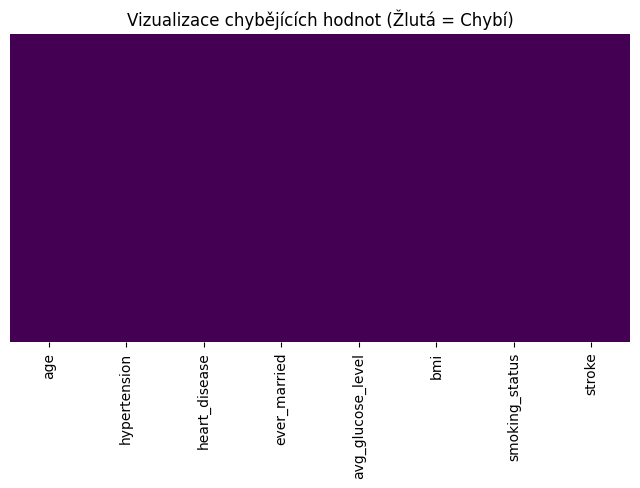

In [87]:
missingDF = df.copy()
missingDF['bmi'] = pd.to_numeric(missingDF['bmi'], errors='coerce')

missing_values = missingDF.isnull().sum()
total_missing = missing_values.sum()
rows_with_missing = missingDF.isnull().any(axis=1).sum()
rows_multi_missing = (missingDF.isnull().sum(axis=1) > 1).sum()

print("Chybějící hodnoty: ")
print(missing_values[missing_values > 0])
print(f"\nCelkový počet chybějících hodnot: {total_missing}")
print(f"Počet řádků s alespoň jednou chybějící hodnotou: {rows_with_missing}")
print(f"Počet řádků s více než jednou chybějící hodnotou: {rows_multi_missing}")

# Vizualizace chybějících hodnot (heatmapa)
plt.figure(figsize=(8, 4))
sns.heatmap(missingDF.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Vizualizace chybějících hodnot (Žlutá = Chybí)')
plt.show()

# Úprava datové sady

## Odstranění irelevantních atributů

In [80]:
df = df.drop(columns=["gender", "work_type", "Residence_type"])
df.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,67.0,0,1,Yes,228.69,36.6,formerly smoked,1
1,61.0,0,0,Yes,202.21,NaN,never smoked,1
2,80.0,0,1,Yes,105.92,32.5,never smoked,1
3,49.0,0,0,Yes,171.23,34.4,smokes,1
4,79.0,1,0,Yes,174.12,24.0,never smoked,1


## Vyřešení chybějících hodnot

Pro vyřešení chybějících hodnotu jsou použity 2 metody a to odstranění zaznamů s chybějící hodnotou a nebo doplnění chybějících hodnot střední hodnotou věkové skupiny dané osoby.
V df_remove_missing je uložena kopie DF ve které jsou záznamy z chybějící BMI hodnotou BMI odstraněny.
Pro df používaný dále provodeme doplnění pomocí střední hodnoty. 

In [81]:
print("Odstranění")
print(f" Počet chybějících hodnot bmi: {df['bmi'].isna().sum()}")
df_remove_missing = df.dropna(subset=['bmi'])
print(f" Počet chybějících hodnot bmi po odstranění: {df_remove_missing['bmi'].isna().sum()}")
print(f" Počet záznamů po odstranění chybějících hodnot bmi: {len(df_remove_missing)}")

print("Doplnění")
print(f" Průměrné BMI v datasetu: {df['bmi'].mean()}")
age_bmi_means = df.groupby('age')['bmi'].mean()
df['bmi'] = df['bmi'].fillna(df['age'].map(age_bmi_means))
print(f" Průměrné BMI v datasetu po doplnění: {df['bmi'].mean()}")
print(f" Počet chybějících hodnot bmi po doplnění: {df['bmi'].isna().sum()}")
print(f" Počet záznamů po doplnění chybějících hodnot bmi: {len(df)}")


Odstranění
 Počet chybějících hodnot bmi: 201
 Počet chybějících hodnot bmi po odstranění: 0
 Počet záznamů po odstranění chybějících hodnot bmi: 4909
Doplnění
 Průměrné BMI v datasetu: 28.893236911794666
 Průměrné BMI v datasetu po doplnění: 28.918277018431663
 Počet chybějících hodnot bmi po doplnění: 0
 Počet záznamů po doplnění chybějících hodnot bmi: 5110


## Odstranění odlehlých hodnot
Pro odstranění odlehlých hodnot u numerických atributů bylo použito Z-score. Kategorické atributy s odlehlými hodnotamy byly odstraněny.

In [82]:
# remove numerical outliers using z-score
columns_to_check = ['avg_glucose_level', 'bmi']
for col in columns_to_check:
    z_scores = np.abs(stats.zscore(df[col]))
    df = df[z_scores <= 3]
print(f"Počet záznamů po odstranění odlehlých hodnot numerických atributů: {len(df)}")


Počet záznamů po odstranění odlehlých hodnot numerických atributů: 5002


### Transformace numerickcýh atributů na kategorické

Kategorizace numerických atributů pomocí metody košu se stejnou četností (do hloubky).

In [83]:
df1 = df.copy()

# Numerical to categorical using depth bins
age_n_bins = 10
age_bin_thrs = [-np.inf] + [df1["age"].quantile(i*1/age_n_bins) for i in range(1, age_n_bins)] + [np.inf]
age_categories = np.array([f"{lower}-{upper}" for lower, upper in zip(age_bin_thrs, age_bin_thrs[1:])])
age_categorized = age_categories[np.digitize(df1["age"], age_bin_thrs, right=False) - 1]

bmi_n_bins = 10
bmi_bin_thrs = [-np.inf] + [df1["bmi"].quantile(i*1/bmi_n_bins) for i in range(1, bmi_n_bins)] + [np.inf]
bmi_categories = np.array([f"{np.round(lower,4)}-{np.round(upper, 4)}" for lower, upper in zip(bmi_bin_thrs, bmi_bin_thrs[1:])])
bmi_categorized = bmi_categories[np.digitize(df1["bmi"], bmi_bin_thrs, right=False) - 1]

glucose_n_bins = 10
glucose_bin_thrs = [-np.inf] + [df1["avg_glucose_level"].quantile(i*1/glucose_n_bins) for i in range(1, glucose_n_bins)] + [np.inf]
glucose_categories = np.array([f"{np.round(lower,4)}-{np.round(upper, 4)}" for lower, upper in zip(glucose_bin_thrs, glucose_bin_thrs[1:])])
glucose_categorized = glucose_categories[np.digitize(df1["avg_glucose_level"], glucose_bin_thrs, right=False) - 1]

print("Age bin counts: ", np.unique(age_categorized, return_counts=True)[1])
print("BMI bin counts: ", np.unique(bmi_categorized, return_counts=True)[1])
print("Glucose bin counts: ", np.unique(glucose_categorized, return_counts=True)[1])

df1.drop(columns=["age", "bmi", "avg_glucose_level"])
df1["age"] = age_categorized
df1["bmi"] = bmi_categorized
df1["avg_glucose_level"] = glucose_categorized
df1.head()

Age bin counts:  [472 492 490 481 494 512 490 528 540 503]
BMI bin counts:  [498 494 497 499 490 516 507 493 500 508]
Glucose bin counts:  [501 501 500 501 499 499 502 500 500 499]


,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke
0,64.0-75.0,0,1,Yes,183.421-inf,34.0-38.0,formerly smoked,1
1,57.0-64.0,0,0,Yes,183.421-inf,29.8-31.6186,never smoked,1
2,75.0-inf,0,1,Yes,98.362-107.52,31.6186-34.0,never smoked,1
3,44.0-51.0,0,0,Yes,122.258-183.421,34.0-38.0,smokes,1
4,75.0-inf,1,0,Yes,122.258-183.421,22.5-24.6,never smoked,1


In [84]:
df1[:100].to_csv("healthcare-dataset-stroke-data-categorical.csv")

### Transformace kategorických atributů na numerické

Kategorické atributy jsou převedeny na numerické pomocí One-Hot Encodingu, kdy je pro každou hodnotu, kterou může kategorický sloupec nabývat vytvořen nový sloupec s hodnotou 0 nebo 1.

In [85]:
df2 = df.copy()

# Categorical to numerical
df2["ever_married"] = df2["ever_married"].map({'Yes': 1, "No": 0})
smoking_status_one_hot = pd.get_dummies(df2["smoking_status"], dtype=int, prefix="smoking_status")
df2 = df2.drop(columns=["smoking_status"])
df2 = pd.concat([df2, smoking_status_one_hot], axis=1)

# Normalization
glucose_min, glucose_max = df2["avg_glucose_level"].min(), df2["avg_glucose_level"].max()
bmi_min, bmi_max = df2["bmi"].min(), df2["bmi"].max()
df2["bmi"] = (df2["bmi"] - bmi_min) / (bmi_max - bmi_min)
df2["avg_glucose_level"] = (df2["avg_glucose_level"] - glucose_min) / (glucose_max - glucose_min)
df2.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,0.934478,0.632212,1,0,1,0,0
1,61.0,0,0,1,0.791913,0.478125,1,0,0,1,0
2,80.0,0,1,1,0.273501,0.533654,1,0,0,1,0
3,49.0,0,0,1,0.625121,0.579327,1,0,0,0,1
4,79.0,1,0,1,0.640681,0.329327,1,0,0,1,0


In [86]:
df2[:100].to_csv("healthcare-dataset-stroke-data-numerical.csv")